In [3]:
import pandas as pd
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import os

In [4]:
df = pd.read_csv('styles.csv', on_bad_lines='skip')

In [ ]:
df.head(10)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,Fabindia Men Striped Green Shirt
7,26960,Women,Apparel,Topwear,Shirts,Purple,Summer,2012.0,Casual,Jealous 21 Women Purple Shirt
8,29114,Men,Accessories,Socks,Socks,Navy Blue,Summer,2012.0,Casual,Puma Men Pack of 3 Socks
9,30039,Men,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,Skagen Men Black Watch


In [6]:
df.isnull().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

In [7]:
df.shape

(44424, 10)

### Feature Engineering

In [8]:
df = df.dropna()

In [9]:
df = df.reset_index(drop=True)

In [10]:
df.isnull().sum()

id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
dtype: int64

In [11]:
df.shape

(44077, 10)

In [12]:
df['content'] = (
    df['gender'] + " " +
    df['masterCategory'] + " " +
    df['subCategory'] + " " +
    df['articleType'] + " " +
    df['baseColour'] + " " +
    df['season'] + " " +
    df['usage']
)

In [13]:
df[['content', "productDisplayName"]].head(10)

,content,productDisplayName
0,Men Apparel Topwear Shirts Navy Blue Fall Casual,Turtle Check Men Navy Blue Shirt
1,Men Apparel Bottomwear Jeans Blue Summer Casual,Peter England Men Party Blue Jeans
2,Women Accessories Watches Watches Silver Winte...,Titan Women Silver Watch
3,Men Apparel Bottomwear Track Pants Black Fall ...,Manchester United Men Solid Black Track Pants
4,Men Apparel Topwear Tshirts Grey Summer Casual,Puma Men Grey T-shirt
5,Men Apparel Topwear Tshirts Grey Summer Casual,Inkfruit Mens Chain Reaction T-shirt
6,Men Apparel Topwear Shirts Green Summer Ethnic,Fabindia Men Striped Green Shirt
7,Women Apparel Topwear Shirts Purple Summer Casual,Jealous 21 Women Purple Shirt
8,Men Accessories Socks Socks Navy Blue Summer C...,Puma Men Pack of 3 Socks
9,Men Accessories Watches Watches Black Winter C...,Skagen Men Black Watch


#### Adding image path to dataframe and visualizing it.

In [14]:
df["image_path"] = df["id"].apply(lambda x: f"images/{x}.jpg")

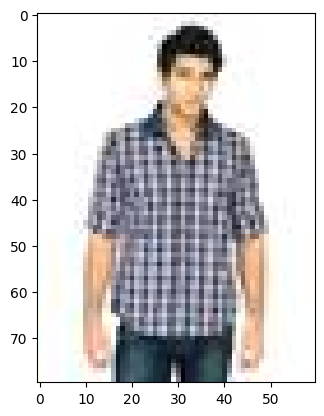

In [15]:
img = Image.open(df["image_path"][0])
plt.imshow(img)
plt.show()

## Feature Vectorization

In [16]:
tfidf = TfidfVectorizer(stop_words='english')

In [17]:
tfidf_matrix = tfidf.fit_transform(df['content'])

## KNN based Recommendation Model

In [18]:
model = NearestNeighbors(metric='cosine', algorithm='brute')
model.fit(tfidf_matrix)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [28]:
def recommend_products(item_index,model, tfidf_matrix):
    query = tfidf_matrix[item_index]
    distances, indices = model.kneighbors(query, n_neighbors=6)
    return indices, distances

In [29]:
def plot_recommendations(item_index, model, tfidf_matrix):    
    plt.figure(figsize=(18, 4))

    product_indices, product_distances = recommend_products(item_index, model, tfidf_matrix)

    for i in product_indices:
        for j in i:
            img = Image.open(df.loc[j, 'image_path'])
            plt.subplot(1, 6, list(i).index(j) + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(df.loc[j, 'productDisplayName'], fontsize=8)

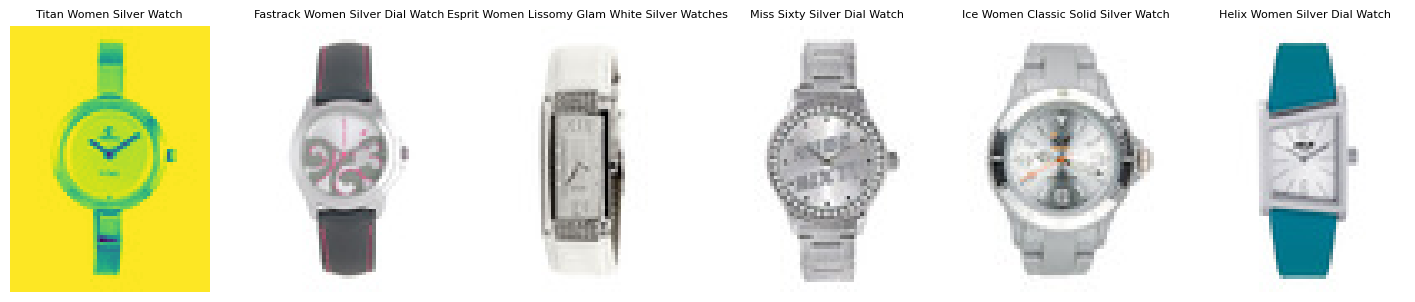

In [31]:
plot_recommendations(2, model, tfidf_matrix)  # change to the product you want recommendations for

In [32]:
pkl.dump(df, open('fashion_products.pkl', 'wb'))
pkl.dump(tfidf_matrix, open('tfidf_matrix.pkl', 'wb'))
pkl.dump(model, open('fashion_recommender_model.pkl', 'wb'))